In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
import string
import re

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [27]:
data = {
'Feedback_ID':[1,2,3,4,5,6,7,8,9,10,
11,12,13,14,15,16,17,18,19,20,
21,22,23,24,25,26,27,28,29,30],

'Client_Name':[
'Ali','Sara','Ahmed','Fatima','Usman',
'Ayesha','Bilal','Hina','Hamza','Noor',
'Asad','Zara','Danish','Iqra','Talha',
'Mariam','Saad','Anum','Omer','Laiba',
'Farhan','Kiran','Waqas','Nimra','Hassan',
'Mehak','Adeel','Sana','Shayan','Rabia'
],

'Service':[
'Web','Mobile','Support','Web','Support',
'Mobile','Web','Support','Web','Mobile',
'Support','Web','Mobile','Support','Web',
'Mobile','Support','Web','Mobile','Support',
'Web','Support','Mobile','Web','Support',
'Mobile','Web','Support','Mobile','Web'
],

'Feedback_Text':[
'Excellent service',
'Very satisfied',
'Good support',
'Amazing experience',
'Fast response',
'Helpful staff',
'Great application',
'Professional team',
'Highly recommended',
'Easy to use',
'Poor support',
'Slow response',
'Bad experience',
'Very disappointed',
'Needs improvement',
'Application crashes often',
'Not satisfied',
'Terrible service',
'Waste of time',
'Unprofessional behavior',
'Excellent support',
'Quick resolution',
'Loved the service',
'Friendly staff',
'Outstanding performance',
'Bad customer support',
'Slow application',
'Needs updates',
'Good overall',
'Fantastic experience'
],

'Rating':[5,5,4,5,4,5,5,5,5,4,
2,2,1,1,2,1,2,1,1,1,
5,4,5,5,5,2,2,2,4,5],

'Sentiment':[
'Positive','Positive','Positive','Positive','Positive',
'Positive','Positive','Positive','Positive','Positive',
'Negative','Negative','Negative','Negative','Negative',
'Negative','Negative','Negative','Negative','Negative',
'Positive','Positive','Positive','Positive','Positive',
'Negative','Negative','Negative','Positive','Positive'
]
}

df = pd.DataFrame(data)
df.head()

,Feedback_ID,Client_Name,Service,Feedback_Text,Rating,Sentiment
0,1,Ali,Web,Excellent service,5,Positive
1,2,Sara,Mobile,Very satisfied,5,Positive
2,3,Ahmed,Support,Good support,4,Positive
3,4,Fatima,Web,Amazing experience,5,Positive
4,5,Usman,Support,Fast response,4,Positive


In [28]:
df.to_csv("coretech_feedback.csv",index=False)

print("CSV Saved Successfully")

CSV Saved Successfully


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Feedback_ID    30 non-null     int64 
 1   Client_Name    30 non-null     object
 2   Service        30 non-null     object
 3   Feedback_Text  30 non-null     object
 4   Rating         30 non-null     int64 
 5   Sentiment      30 non-null     object
dtypes: int64(2), object(4)
memory usage: 1.5+ KB


In [30]:
df.describe()

,Feedback_ID,Rating
count,30.000000,30.000000
mean,15.500000,3.333333
std,8.803408,1.667816
min,1.000000,1.000000
25%,8.250000,2.000000
50%,15.500000,4.000000
75%,22.750000,5.000000
max,30.000000,5.000000


In [31]:
df['Sentiment'].value_counts()

,count
Sentiment,
Positive,17
Negative,13


In [32]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [33]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import re

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

In [34]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)

    words = word_tokenize(text)

    words = [word for word in words if word not in stop_words]

    words = [stemmer.stem(word) for word in words]

    return " ".join(words)

df['Cleaned_Text'] = df['Feedback_Text'].apply(clean_text)

df[['Feedback_Text','Cleaned_Text']].head()

,Feedback_Text,Cleaned_Text
0,Excellent service,excel servic
1,Very satisfied,satisfi
2,Good support,good support
3,Amazing experience,amaz experi
4,Fast response,fast respons


In [35]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['Cleaned_Text'])

y = df['Sentiment']

print(X.shape)

(30, 42)


In [36]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(24, 42)
(6, 42)


In [37]:
model = MultinomialNB()

model.fit(X_train,y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test,predictions)

print("Accuracy:",accuracy)

Accuracy: 0.6666666666666666


In [38]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

    Negative       1.00      0.33      0.50         3
    Positive       0.60      1.00      0.75         3

    accuracy                           0.67         6
   macro avg       0.80      0.67      0.62         6
weighted avg       0.80      0.67      0.62         6



[[1 2]
 [0 3]]


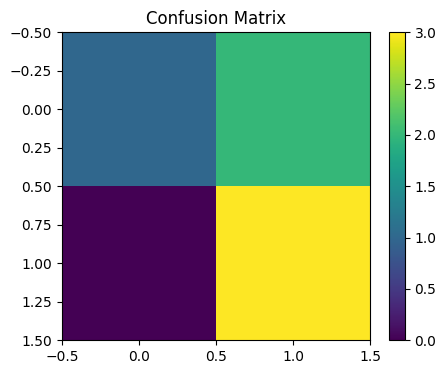

In [39]:
cm = confusion_matrix(y_test,predictions)

print(cm)

plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.colorbar()
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

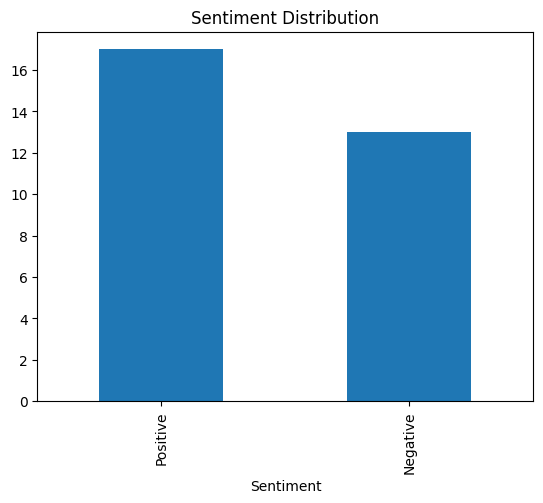

In [40]:
df['Sentiment'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")

plt.savefig("sentiment_distribution.png")

plt.show()

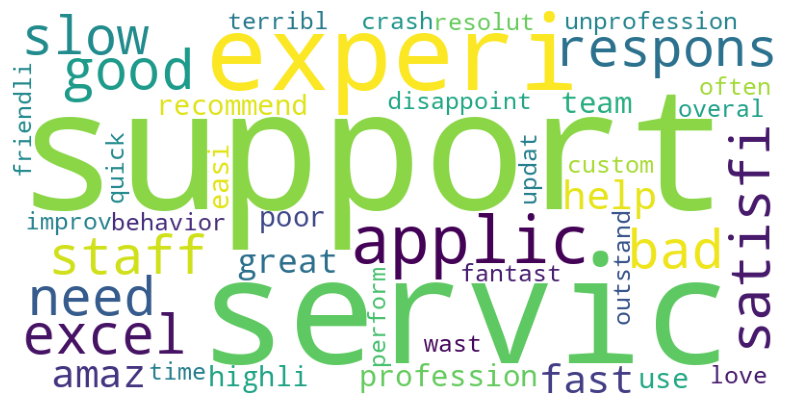

In [41]:
text = " ".join(df['Cleaned_Text'])

wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wc)

plt.axis('off')

plt.savefig("wordcloud.png")

plt.show()

In [42]:
results = pd.DataFrame({
    'Actual':y_test,
    'Predicted':predictions
})

results.to_csv(
    "sentiment_predictions.csv",
    index=False
)

results.head()

,Actual,Predicted
27,Negative,Negative
15,Negative,Positive
23,Positive,Positive
17,Negative,Positive
8,Positive,Positive


In [43]:
# Save CSV
df.to_csv("coretech_feedback.csv", index=False)

print("CSV file created successfully!")

CSV file created successfully!


In [44]:
from google.colab import files

files.download("coretech_feedback.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
results.to_csv("sentiment_predictions.csv", index=False)

from google.colab import files

files.download("sentiment_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
files.download("confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [47]:
files.download("sentiment_distribution.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
files.download("wordcloud.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>